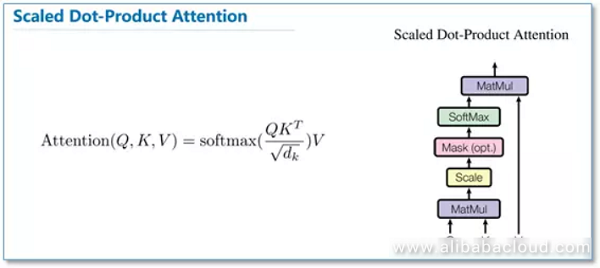

X : (seq_length , d_model)<br>

Q : (seqlength , d_k ) <br>
K : (seqlength , d_k )<br>
V : (seqlength , d_v )<br>

Wq : (d_model , d_k)<br>
Wk : (d_model , d_k)<br>
Wv : (d_model , d_v)<br>


# per head
Wq_i : (d_model, d_k)   where d_k = d_model / n_heads<br>
Wk_i : (d_model, d_k)<br>
Wv_i : (d_model, d_k)<br>

head_i : (seq_len, d_k)<br>

# after all heads<br>
concat : (seq_len, d_model)   ← n_heads * d_k = d_model<br>

# final projection<br>
Wo     : (d_model, d_model)<br>
output : (seq_len, d_model)<br>


weight : (seq_length , seq_length)<br>
output : (seq_len, d_v)<br>

X (3, 4) <br>
    │<br>
    ├──────────────────┐<br>
    ↓                  ↓<br>
@ Wq1,Wk1,Wv1     @ Wq2,Wk2,Wv2<br>
    ↓                  ↓
attention1(3,2)   attention2(3,2)<br>
    │                  │<br>
    └────────┬──────────┘<br>
             ↓<br>
    concat(3, 4)<br>
             ↓<br>
          @ Wo(4,4)<br>
             ↓<br>
       output(3, 4)<br>

In [12]:
import numpy as np

X = np.array([
    [1.0, 0.0, 1.0, 0.0],  # "I"
    [0.0, 1.0, 0.0, 1.0],  # "love"
    [1.0, 1.0, 0.0, 0.0],  # "cats"
])

# d_model = 4, n_heads = 2, d_k = 4/2 = 2
d_model = 4
n_heads = 2
d_k = d_model // n_heads  # = 2


Wq_1 = np.random.randn(d_model , d_k)
Wk_1 = np.random.randn(d_model , d_k)
Wv_1 = np.random.randn(d_model , d_k)

Wq_2= np.random.randn(d_model , d_k)
Wk_2 = np.random.randn(d_model , d_k)
Wv_2 = np.random.randn(d_model , d_k)

# Head 1
Q1 = X @ Wq_1
K1 = X @ Wk_1
V1 = X @ Wv_1

# Head 2
Q2 = X @ Wq_2
K2 = X @ Wk_2
V2 = X @ Wv_2

score1 = (Q1@K1.T)/np.sqrt(d_k)
score2 = (Q2@K2.T)/np.sqrt(d_k)


weight1 = []
for i in score1 :
    z = [] 
    all_values = np.sum(np.exp(i)) 
    for row in i : 
        c = np.exp(row) / all_values
        z.append(c)
    weight1.append(z)


weight2 = []

for i in score2 :
    z = [] 
    all_values = np.sum(np.exp(i)) 
    for row in i : 
        c = np.exp(row) / all_values
        z.append(c)
    weight2.append(z)

weight1 = np.array(weight1)
weight2 = np.array(weight2)

head1 = weight1 @ V1
head2 = weight2 @ V2

Wo = np.random.randn(d_model, d_model)

final_weight = np.concatenate([head1 , head2] , axis=1)

result = final_weight@Wo
result


array([[-0.43672315, -0.9158507 , -0.9018117 , -0.12441487],
       [-0.38476922, -0.7054138 , -0.67732434, -0.22931689],
       [ 0.66427635, -1.67537868, -0.41939057, -0.20063169]])

In [13]:
import numpy as np

def positional_encoding(seq_len, d_model):
    PE = np.zeros((seq_len, d_model))
    
    for pos in range(seq_len):
        for i in range(0, d_model, 2):
            PE[pos, i]   = np.sin(pos / 10000 ** (2*i / d_model))
            PE[pos, i+1] = np.cos(pos / 10000 ** (2*i / d_model))
    
    return PE

PE = positional_encoding(3, 4)
print(PE)



[[ 0.00000000e+00  1.00000000e+00  0.00000000e+00  1.00000000e+00]
 [ 8.41470985e-01  5.40302306e-01  9.99999998e-05  9.99999995e-01]
 [ 9.09297427e-01 -4.16146837e-01  1.99999999e-04  9.99999980e-01]]


In [14]:
X_with_position = X + PE
print(X_with_position.shape)  # (3, 4)

(3, 4)
